<a href="https://colab.research.google.com/github/marysanthra01/drug-recommendation-system/blob/main/project_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [ ]:
train=pd.read_csv('/content/drive/MyDrive/data_drug/drugsComTrain_raw.csv')
test=pd.read_csv('/content/drive/MyDrive/data_drug/drugsComTest_raw.csv')
train_df=pd.concat([train,test])
train_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [ ]:
train_df['sentiment'] = train_df['rating'].apply(lambda rating : 1 if rating >  6 else 0)
train_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27,1
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,1
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,0
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10,1
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,1


In [ ]:
train_df = pd.DataFrame(train_df)

# Drop the 'Date' and 'Unique ID' columns
train_df = train_df.drop(['uniqueID', 'date'], axis=1)

In [ ]:
train_df.head()

,drugName,condition,review,rating,usefulCount,sentiment
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,27,1
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,192,1
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,17,0
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,10,1
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,37,1


In [ ]:
train_df.isnull().sum()

drugName          0
condition      1194
review            0
rating            0
usefulCount       0
sentiment         0
dtype: int64

In [ ]:
train_df['condition'].fillna('Unknown', inplace=True)
train_df.isnull().sum()

drugName       0
condition      0
review         0
rating         0
usefulCount    0
sentiment      0
dtype: int64

In [ ]:
train_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
53761    False
53762    False
53763    False
53764    False
53765    False
Length: 215063, dtype: bool

In [ ]:
train_df.shape

(215063, 6)

1    142306
0     72757
Name: sentiment, dtype: int64

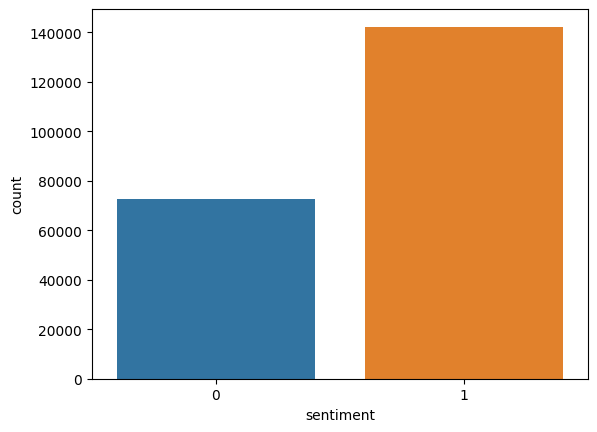

In [ ]:
import seaborn as sns
sns.countplot(x='sentiment',data=train_df)
train_df['sentiment'].value_counts()

In [ ]:
import string

In [ ]:
train_df['review']=train_df['review'].str.replace('[{}]'.format(string.punctuation), '')
#filling nan values with space(' ')
train_df.fillna(' ',inplace=True)

<ipython-input-13-bbca95bd9e8e>:1: FutureWarning: The default value of regex will change from True to False in a future version.
  train_df['review']=train_df['review'].str.replace('[{}]'.format(string.punctuation), '')


In [ ]:
x=train_df['review']
#corpus=train_df['review']

In [ ]:
y=train_df['sentiment']

In [ ]:
x.head()

0    It has no side effect I take it in combination...
1    My son is halfway through his fourth week of I...
2    I used to take another oral contraceptive whic...
3    This is my first time using any form of birth ...
4    Suboxone has completely turned my life around ...
Name: review, dtype: object

In [ ]:
x[1]

1    My son is halfway through his fourth week of I...
1    My son has Crohn039s disease and has done very...
Name: review, dtype: object

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import nltk
import re
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
ps=PorterStemmer()

In [ ]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    '''Removes HTML tags: replaces anything between opening and closing <> with empty space'''

    return TAG_RE.sub('', text)

def preprocess_text(sen):
    '''Cleans text data up, leaving only 2 or more char long non-stepwords composed of A-Z & a-z only
    in lowercase'''

    sentence = sen.lower()

    # Remove html tags
    sentence = remove_tags(sentence)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)  # When we remove apostrophe from the word "Mark's", the apostrophe is replaced by an empty space. Hence, we are left with single character "s" that we are removing here.

    # Remove multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)  # Next, we remove all the single characters and replace it by a space which creates multiple spaces in our text. Finally, we remove the multiple spaces from our text as well.

    # Remove Stopwords
    pattern = re.compile(r'\b(' + r'|'.join(stopwords.words('english')) + r')\b\s*')
    sentence = pattern.sub('', sentence)

    return sentence

In [ ]:
corpus = []
sentences = list(x)
for sen in sentences:
    corpus.append(preprocess_text(sen))

In [ ]:
corpus[1]

'son halfway fourth week intuniv became concerned began last week started taking highest dose two days could hardly get bed cranky slept nearly hours drive home school vacation unusual called doctor monday morning said stick days see school getting morning last two days problem free much agreeable ever less emotional good thing less cranky remembering things overall behavior better tried many different medications far effective'

In [ ]:
#vocabulary size
voc_size=10000

In [ ]:
# TensorFlow has an operation for one-hot encoding
one_hot_reps1=[one_hot(word,voc_size) for word in corpus]
one_hot_reps1[1]

[734,
 1559,
 6617,
 7870,
 654,
 2270,
 7371,
 8056,
 5144,
 7870,
 6930,
 397,
 5747,
 326,
 3414,
 3674,
 661,
 8436,
 61,
 4055,
 5900,
 307,
 4725,
 254,
 8613,
 4571,
 3379,
 8416,
 8745,
 1319,
 5479,
 7602,
 6030,
 8621,
 5905,
 3674,
 7732,
 3379,
 2355,
 6030,
 5144,
 3414,
 3674,
 8515,
 9052,
 4523,
 6653,
 5722,
 4115,
 5100,
 5750,
 9603,
 4115,
 5900,
 3639,
 4939,
 3428,
 4122,
 685,
 8826,
 6724,
 8839,
 3543,
 9743,
 6943]

In [ ]:
# here we are specifying a sentence length so that every sentence in the corpus will be of same length
sent_length=500
#making all the sentence as equall size vector
#two types of padding pre and post
embedded_docs1=pad_sequences(one_hot_reps1,padding='pre',maxlen=sent_length)
embedded_docs1


array([[   0,    0,    0, ..., 8540, 6188, 7515],
       [   0,    0,    0, ..., 3543, 9743, 6943],
       [   0,    0,    0, ..., 9052, 7374, 3464],
       ...,
       [   0,    0,    0, ..., 5929, 3428, 5056],
       [   0,    0,    0, ..., 4116, 9261, 5398],
       [   0,    0,    0, ...,    0,    0, 5700]], dtype=int32)

In [ ]:
x=np.array(embedded_docs1)
y=np.array(y)
y

array([1, 1, 0, ..., 1, 0, 1])

In [ ]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [ ]:
x

array([[   0,    0,    0, ..., 8540, 6188, 7515],
       [   0,    0,    0, ..., 3543, 9743, 6943],
       [   0,    0,    0, ..., 9052, 7374, 3464],
       ...,
       [   0,    0,    0, ..., 5929, 3428, 5056],
       [   0,    0,    0, ..., 4116, 9261, 5398],
       [   0,    0,    0, ...,    0,    0, 5700]], dtype=int32)

In [ ]:
# Create model using BiLSTM(Rnn)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

embedded_feature_vector = 300
voc_size = 10000  # Replace with your vocabulary size
sent_length = 500  # Replace with your sentence length

model = Sequential([
    Embedding(input_dim=voc_size, output_dim=embedded_feature_vector, input_length=sent_length),
    Bidirectional(LSTM(64, return_sequences=True)),  # Bidirectional LSTM layer
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])




In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 500, 300)          3000000   
                                                                 
 bidirectional (Bidirection  (None, 500, 128)          186880    
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 128)               98816     
 onal)                                                           
                                                                 
 dense (Dense)               (None, 256)               33024     
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 2

In [ ]:
# here we are splitting the data for training and testing the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.22, random_state=42)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#nn.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)
# Train the model on the training data with validation split
history=model.fit(X_train, y_train, validation_split=0.25, epochs=10, batch_size=64)

Epoch 1/10
1966/1966 [==============================] - 220s 105ms/step - loss: 0.4220 - accuracy: 0.8098 - val_loss: 0.3813 - val_accuracy: 0.8305
Epoch 2/10
1966/1966 [==============================] - 168s 85ms/step - loss: 0.3319 - accuracy: 0.8590 - val_loss: 0.3629 - val_accuracy: 0.8434
Epoch 3/10
1966/1966 [==============================] - 163s 83ms/step - loss: 0.2634 - accuracy: 0.8928 - val_loss: 0.3557 - val_accuracy: 0.8560
Epoch 4/10
1966/1966 [==============================] - 163s 83ms/step - loss: 0.2014 - accuracy: 0.9217 - val_loss: 0.3642 - val_accuracy: 0.8627
Epoch 5/10
1966/1966 [==============================] - 162s 82ms/step - loss: 0.1462 - accuracy: 0.9460 - val_loss: 0.4036 - val_accuracy: 0.8686
Epoch 6/10
1966/1966 [==============================] - 161s 82ms/step - loss: 0.1051 - accuracy: 0.9624 - val_loss: 0.4693 - val_accuracy: 0.8731
Epoch 7/10
1966/1966 [==============================] - 166s 84ms/step - loss: 0.0758 - accuracy: 0.9733 - val_loss: 

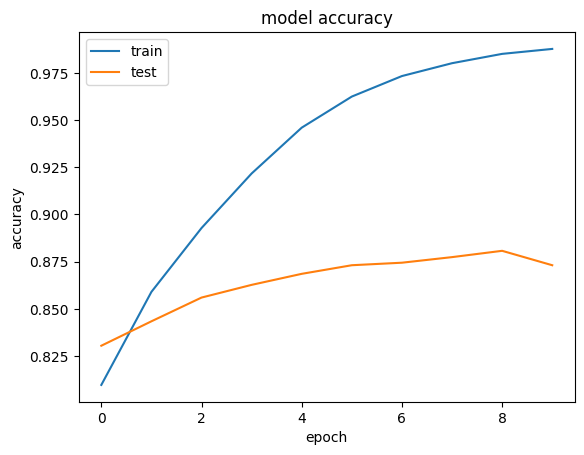

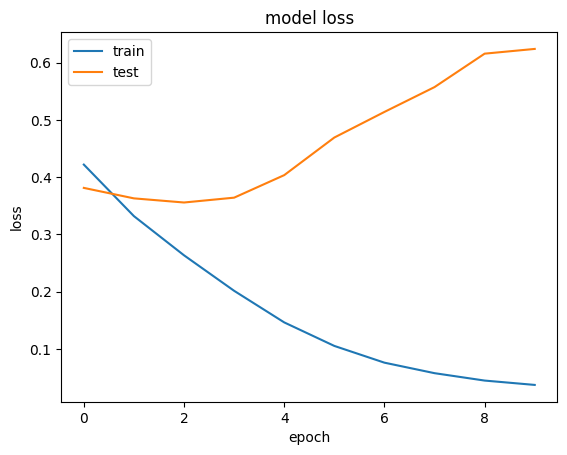

In [ ]:
   # Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
score=model.evaluate(X_test,y_test,verbose=1)

1479/1479 [==============================] - 39s 26ms/step - loss: 0.6261 - accuracy: 0.8720


In [ ]:
print('Test accuracy:',score[1])

Test accuracy: 0.872025191783905


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred=model.predict(X_train)

5243/5243 [==============================] - 132s 25ms/step


In [ ]:
y_pred = y_pred.round().astype(int)

In [ ]:
cm=confusion_matrix(y_train,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 54378   2315]
 [  4245 106811]]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

0.9608939546584481

In [ ]:
y_pred=(y_pred>0.5)
y_pred

array([[ True],
       [ True],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
y_pred=y_pred.reshape(-1,)
y_pred

array([ True,  True, False, ..., False, False, False])

In [ ]:
y_train

array([1, 1, 0, ..., 0, 1, 0])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     56693
           1       0.98      0.96      0.97    111056

    accuracy                           0.96    167749
   macro avg       0.95      0.96      0.96    167749
weighted avg       0.96      0.96      0.96    167749



In [ ]:
# Create the model using CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

embedded_feature_vector = 300
voc_size = 10000  # Replace with your vocabulary size
sent_length = 500  # Replace with your sentence length

cnn_model = Sequential([
    Embedding(input_dim=voc_size, output_dim=embedded_feature_vector, input_length=sent_length),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.summary()





Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 500, 300)          3000000   
                                                                 
 conv1d (Conv1D)             (None, 498, 64)           57664     
                                                                 
 max_pooling1d (MaxPooling1  (None, 249, 64)           0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 247, 128)          24704     
                                                                 
 global_max_pooling1d (Glob  (None, 128)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense_2 (Dense)             (None, 256)              

In [ ]:
# here we are splitting the data for training and testing the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.22, random_state=42)

In [ ]:
cnn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#nn.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)
# Train the model on the training data with validation split
history=cnn_model.fit(X_train, y_train, validation_split=0.25, epochs=10, batch_size=64)

Epoch 1/10
1966/1966 [==============================] - 66s 30ms/step - loss: 0.4341 - accuracy: 0.8013 - val_loss: 0.3833 - val_accuracy: 0.8305
Epoch 2/10
1966/1966 [==============================] - 31s 16ms/step - loss: 0.3023 - accuracy: 0.8755 - val_loss: 0.3509 - val_accuracy: 0.8517
Epoch 3/10
1966/1966 [==============================] - 29s 15ms/step - loss: 0.1888 - accuracy: 0.9284 - val_loss: 0.3438 - val_accuracy: 0.8749
Epoch 4/10
1966/1966 [==============================] - 28s 14ms/step - loss: 0.1106 - accuracy: 0.9598 - val_loss: 0.3796 - val_accuracy: 0.8791
Epoch 5/10
1966/1966 [==============================] - 28s 14ms/step - loss: 0.0734 - accuracy: 0.9732 - val_loss: 0.4360 - val_accuracy: 0.8812
Epoch 6/10
1966/1966 [==============================] - 30s 15ms/step - loss: 0.0544 - accuracy: 0.9804 - val_loss: 0.5124 - val_accuracy: 0.8776
Epoch 7/10
1966/1966 [==============================] - 30s 15ms/step - loss: 0.0457 - accuracy: 0.9838 - val_loss: 0.5513 -

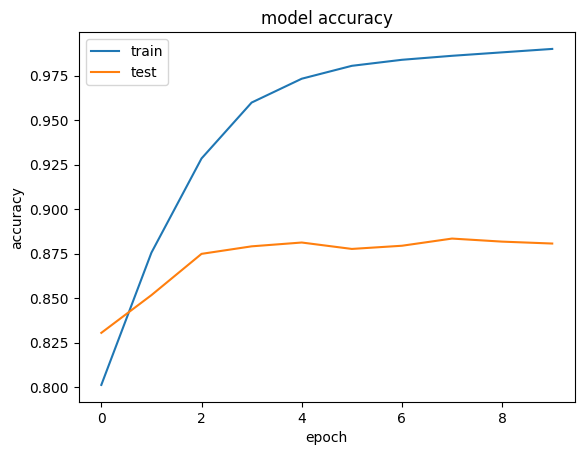

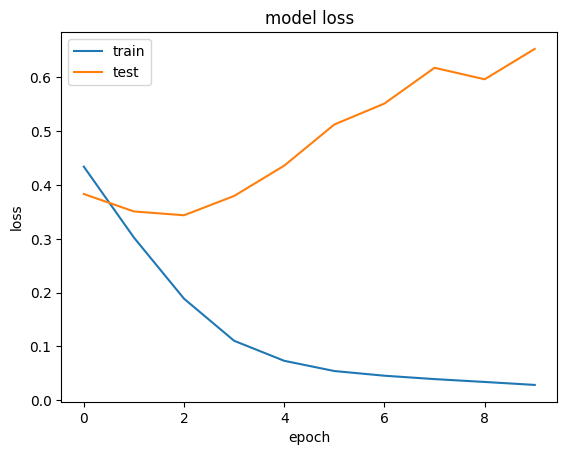

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
score=cnn_model.evaluate(X_test,y_test,verbose=1)

1479/1479 [==============================] - 6s 4ms/step - loss: 0.6708 - accuracy: 0.8796


In [ ]:
print('Test accuracy:',score[1])

Test accuracy: 0.8796339631080627


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred=cnn_model.predict(X_train)

5243/5243 [==============================] - 12s 2ms/step


In [ ]:
y_pred = y_pred.round().astype(int)

In [ ]:
cm=confusion_matrix(y_train,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 54090   2603]
 [  3052 108004]]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

0.9662889197551103

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     56693
           1       0.98      0.97      0.97    111056

    accuracy                           0.97    167749
   macro avg       0.96      0.96      0.96    167749
weighted avg       0.97      0.97      0.97    167749



In [ ]:
# Create model using ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout

embedded_feature_vector = 300
voc_size = 10000  # Replace with your vocabulary size
sent_length = 500  # Replace with your sentence length

ann_model = Sequential([
    Embedding(input_dim=voc_size, output_dim=embedded_feature_vector, input_length=sent_length),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Flatten(),  # Flatten the 2D output to a 1D vector
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

ann_model.summary()  # To see the model summary

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 500, 300)          3000000   
                                                                 
 conv1d_2 (Conv1D)           (None, 498, 64)           57664     
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 249, 64)           0         
 g1D)                                                            
                                                                 
 conv1d_3 (Conv1D)           (None, 247, 128)          24704     
                                                                 
 global_max_pooling1d_1 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                               
                                                                 
 flatten (Flatten)           (None, 128)              

In [ ]:
# here we are splitting the data for training and testing the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.22, random_state=42)

In [ ]:
ann_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#nn.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)
# Train the model on the training data with validation split
history=ann_model.fit(X_train, y_train, validation_split=0.25, epochs=10, batch_size=64)

Epoch 1/10
1966/1966 [==============================] - 60s 30ms/step - loss: 0.4315 - accuracy: 0.8014 - val_loss: 0.4193 - val_accuracy: 0.8150
Epoch 2/10
1966/1966 [==============================] - 32s 16ms/step - loss: 0.2970 - accuracy: 0.8774 - val_loss: 0.3384 - val_accuracy: 0.8597
Epoch 3/10
1966/1966 [==============================] - 28s 14ms/step - loss: 0.1830 - accuracy: 0.9306 - val_loss: 0.3561 - val_accuracy: 0.8675
Epoch 4/10
1966/1966 [==============================] - 30s 15ms/step - loss: 0.1058 - accuracy: 0.9614 - val_loss: 0.4002 - val_accuracy: 0.8792
Epoch 5/10
1966/1966 [==============================] - 28s 14ms/step - loss: 0.0695 - accuracy: 0.9746 - val_loss: 0.4642 - val_accuracy: 0.8787
Epoch 6/10
1966/1966 [==============================] - 30s 15ms/step - loss: 0.0543 - accuracy: 0.9805 - val_loss: 0.5443 - val_accuracy: 0.8743
Epoch 7/10
1966/1966 [==============================] - 27s 14ms/step - loss: 0.0435 - accuracy: 0.9845 - val_loss: 0.6284 -

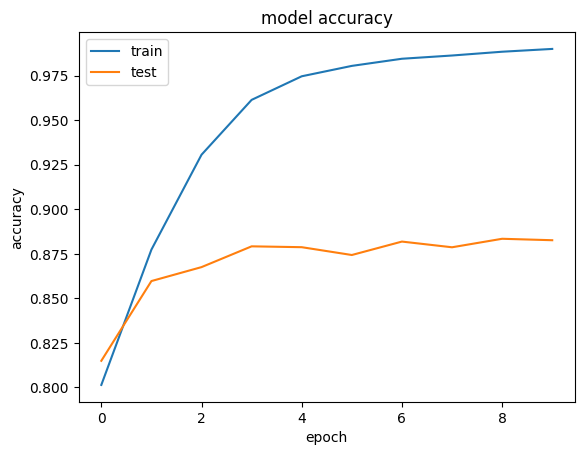

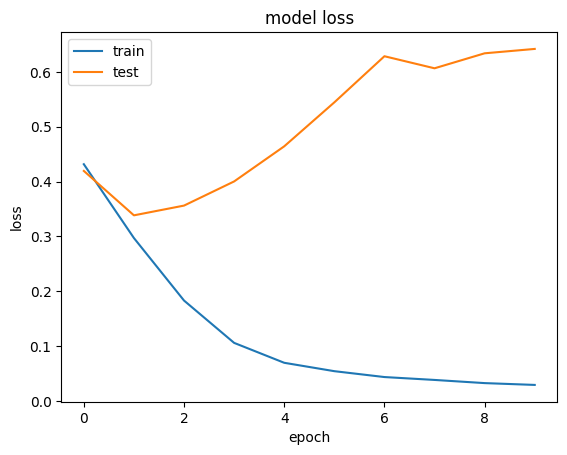

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
score=ann_model.evaluate(X_test,y_test,verbose=1)

1479/1479 [==============================] - 6s 4ms/step - loss: 0.6445 - accuracy: 0.8817


In [ ]:
print('Test accuracy:',score[1])

Test accuracy: 0.8817052245140076


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred=ann_model.predict(X_train)

5243/5243 [==============================] - 12s 2ms/step


In [ ]:
y_pred = y_pred.round().astype(int)

In [ ]:
cm=confusion_matrix(y_train,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 53429   3264]
 [  2228 108828]]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train,y_pred)

0.9672606096012495

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     56693
           1       0.97      0.98      0.98    111056

    accuracy                           0.97    167749
   macro avg       0.97      0.96      0.96    167749
weighted avg       0.97      0.97      0.97    167749



In [ ]:
# Create model using BiLSTM(Rnn)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

embedded_feature_vector = 300
voc_size = 10000  # Replace with your vocabulary size
sent_length = 500  # Replace with your sentence length

model = Sequential([
    Embedding(input_dim=voc_size, output_dim=embedded_feature_vector, input_length=sent_length),
    Bidirectional(LSTM(64, return_sequences=True)),  # Bidirectional LSTM layer
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
# Create the model using CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

embedded_feature_vector = 300
voc_size = 10000  # Replace with your vocabulary size
sent_length = 500  # Replace with your sentence length

cnn_model = Sequential([
    Embedding(input_dim=voc_size, output_dim=embedded_feature_vector, input_length=sent_length),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Create model using ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout

embedded_feature_vector = 300
voc_size = 10000  # Replace with your vocabulary size
sent_length = 500  # Replace with your sentence length

ann_model = Sequential([
    Embedding(input_dim=voc_size, output_dim=embedded_feature_vector, input_length=sent_length),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Flatten(),  # Flatten the 2D output to a 1D vector
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
models = [model, cnn_model, ann_model]




In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define your models
models = [model, cnn_model, ann_model]
# Define model names
model_names = ["BiLSTM", "CNN", "ANN"]

In [ ]:
# Initialize an empty dictionary to store validation accuracies
validation_accuracies = {}

In [ ]:
# Loop through the models, train, and evaluate
for i, model in enumerate(models):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)
    validation_accuracies[model_names[i]] = history.history['val_accuracy'][-1]

Epoch 1/5
2622/2622 [==============================] - 249s 92ms/step - loss: 0.4107 - accuracy: 0.8152 - val_loss: 0.3677 - val_accuracy: 0.8365
Epoch 2/5
2622/2622 [==============================] - 217s 83ms/step - loss: 0.3173 - accuracy: 0.8660 - val_loss: 0.3357 - val_accuracy: 0.8581
Epoch 3/5
2622/2622 [==============================] - 212s 81ms/step - loss: 0.2427 - accuracy: 0.9030 - val_loss: 0.3294 - val_accuracy: 0.8725
Epoch 4/5
2622/2622 [==============================] - 211s 80ms/step - loss: 0.1753 - accuracy: 0.9335 - val_loss: 0.3232 - val_accuracy: 0.8854
Epoch 5/5
2622/2622 [==============================] - 209s 80ms/step - loss: 0.1219 - accuracy: 0.9557 - val_loss: 0.3629 - val_accuracy: 0.8979
Epoch 1/5
2622/2622 [==============================] - 68s 26ms/step - loss: 0.4213 - accuracy: 0.8074 - val_loss: 0.3557 - val_accuracy: 0.8450
Epoch 2/5
2622/2622 [==============================] - 40s 15ms/step - loss: 0.2814 - accuracy: 0.8853 - val_loss: 0.3130 - v

In [ ]:
# Convert the validation accuracies to a 2D numpy array
accuracy_matrix = np.array(list(validation_accuracies.values())).reshape(1, -1)

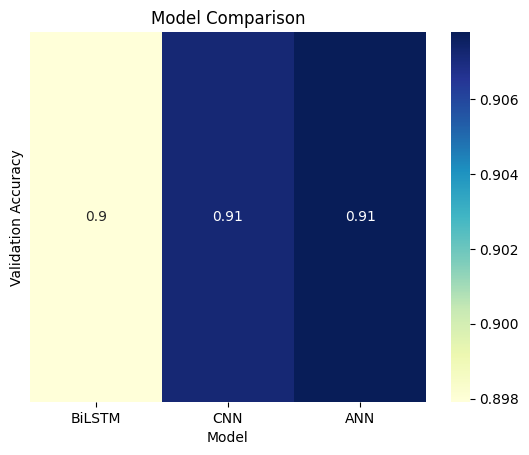

In [ ]:
# Create a heatmap
sns.heatmap(accuracy_matrix, annot=True, cmap="YlGnBu", xticklabels=model_names, yticklabels=False)
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.show()

In [ ]:
# Find the best model based on the highest validation accuracy
best_model = max(validation_accuracies, key=validation_accuracies.get)
print(f"The best model is {best_model} with a validation accuracy of {validation_accuracies[best_model]}")

The best model is ANN with a validation accuracy of 0.9077862501144409


In [ ]:
# Find the low model based on the lowest validation accuracy
low_model = min(validation_accuracies, key=validation_accuracies.get)
print(f"The low model is {low_model} with a validation accuracy of {validation_accuracies[low_model]}")

The low model is BiLSTM with a validation accuracy of 0.8979160785675049
